In [1]:
r"""
========================================
PDA from a synthetic photon distribution
========================================

Photon Distribution Analysis (PDA) starts from a probability distribution for
the total fluorescence photons, ``P(F)``, and predicts how those photons split
between two detection channels. This small example is intentionally synthetic:
it shows the object contract before moving to data-backed single-molecule PDA
examples.

The model below has two species. The first species is more likely to emit into
channel 2, the second into channel 1. In a FRET workflow these channel
probabilities are usually connected to a proximity ratio or corrected FRET
efficiency.
"""

'\n========================================\nPDA from a synthetic photon distribution\n========================================\n\nPhoton Distribution Analysis (PDA) starts from a probability distribution for\nthe total fluorescence photons, ``P(F)``, and predicts how those photons split\nbetween two detection channels. This small example is intentionally synthetic:\nit shows the object contract before moving to data-backed single-molecule PDA\nexamples.\n\nThe model below has two species. The first species is more likely to emit into\nchannel 2, the second into channel 1. In a FRET workflow these channel\nprobabilities are usually connected to a proximity ratio or corrected FRET\nefficiency.\n'

In [2]:
import matplotlib.pyplot as plt
import numpy as np

In [3]:
import tttrlib

In [4]:
n_photons = 60
photon_axis = np.arange(n_photons + 1)

In [5]:
# A simple normalized P(F): most windows contain around 28 fluorescence photons.
pF = np.exp(-0.5 * ((photon_axis - 28.0) / 7.0) ** 2)
pF /= pF.sum()

In [6]:
pda = tttrlib.Pda(
    hist2d_nmax=n_photons,
    hist2d_nmin=10,
    background_ch1=1.5,
    background_ch2=0.8,
    pF=pF,
    implementation=tttrlib.PDA_DEFAULT,
)

In [7]:
# Two species: amplitude, probability that a fluorescence photon lands in ch1.
pda.append(0.55, 0.25)
pda.append(0.45, 0.72)

In [8]:
s1s2 = pda.s1s2

In [9]:
def proximity_ratio(ch1, ch2):
    return ch2 / max(1, ch1 + ch2)

In [10]:
pda.histogram_function = proximity_ratio
projection_x, projection_y = pda.get_1dhistogram(
    log_x=False,
    x_min=0.0,
    x_max=1.0,
    n_bins=31,
)

Text(0, 0.5, 'photons in channel 2')

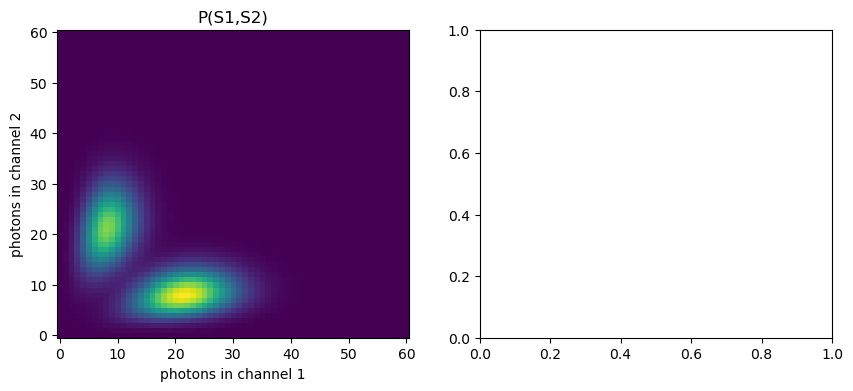

In [11]:
fig, ax = plt.subplots(ncols=2, figsize=(10, 4))
ax[0].imshow(s1s2, origin="lower", aspect="auto")
ax[0].set_title("P(S1,S2)")
ax[0].set_xlabel("photons in channel 1")
ax[0].set_ylabel("photons in channel 2")

In [12]:
ax[1].plot(projection_x, projection_y)
ax[1].set_title("1D proximity-ratio projection")
ax[1].set_xlabel("S2 / (S1 + S2)")
ax[1].set_ylabel("probability")
plt.tight_layout()
plt.show()

<Figure size 640x480 with 0 Axes>

In [13]:
print("Synthetic PDA")
print("=============")
print(f"S1/S2 shape: {s1s2.shape}")
print(f"S1/S2 probability sum: {s1s2.sum():.6f}")
print(f"projection bins: {len(projection_x)}")
print(f"projection probability sum: {projection_y.sum():.6f}")

Synthetic PDA
S1/S2 shape: (61, 61)
S1/S2 probability sum: 0.999988
projection bins: 31
projection probability sum: 0.997794
